In [4]:
import pandas as pd
df = pd.read_csv("./data/feature/full_feature_data.csv", encoding="utf-8-sig")

from pyecharts.charts import Bar
from pyecharts import options as opts
import os

# 剔除 NaN，取整转字符串
cate_data = df["category_id"].dropna().value_counts().sort_index()

bar = (
    Bar()
    .add_xaxis([str(int(x)) for x in cate_data.index])          # 转整数显示
    .add_yaxis("类目订单量", [int(v) for v in cate_data.values])
    .set_global_opts(
        title_opts=opts.TitleOpts(title="商品类目销量交互式分析图"),
        xaxis_opts=opts.AxisOpts(axislabel_opts=opts.LabelOpts(rotate=45)),  # 标签旋转防重叠
    )
)

# 确保目录存在再保存
os.makedirs("./img", exist_ok=True)
bar.render("./img/交互式类目销量图.html")
print("✅ 交互式图表已生成至img目录！")

✅ 交互式图表已生成至img目录！


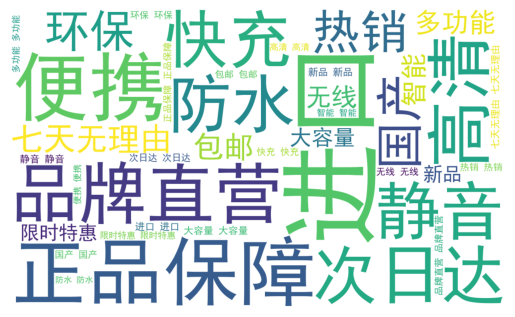

In [10]:
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt

def read_big_csv(file_path, chunk_size=10000):
    chunk_list = []
    # 分块读取+容错编码
    for chunk in pd.read_csv(file_path, chunksize=chunk_size,
                             encoding="utf-8-sig", encoding_errors="ignore"):
        chunk_list.append(chunk)
    df = pd.concat(chunk_list, ignore_index=True)
    return df
    
df_products = read_big_csv("./data/raw/products.csv")
# 拼接所有商品标签
text = ""
tags_series = df_products["tags"].dropna()
for tag in tags_series:
    text += " ".join(str(tag).split(",")) + " "

# 生成词云
wc = WordCloud(
    width=1000, height=600,
    background_color="white",
    font_path="C:/Windows/Fonts/simhei.ttf"
).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.savefig("./img/商品标签词云.png", dpi=300, bbox_inches="tight")
plt.show()